In [ ]:
import kagglehub

path = kagglehub.dataset_download("mansoordaku/ckdisease")
print("Dataset Path:", path)

Using Colab cache for faster access to the 'ckdisease' dataset.
Dataset Path: /kaggle/input/ckdisease


In [ ]:
import pandas as pd

df = pd.read_csv(path + "/kidney_disease.csv")

print("\n Original Dataset:")
display(df.head(100))


 Original Dataset:


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,62.0,90.0,1.015,1.0,0.0,NaN,normal,notpresent,notpresent,...,NaN,NaN,NaN,yes,no,no,good,yes,yes,ckd
96,96,60.0,80.0,1.010,1.0,1.0,NaN,normal,notpresent,notpresent,...,36,NaN,NaN,no,yes,yes,poor,no,no,ckd
97,97,65.0,60.0,1.015,1.0,0.0,NaN,normal,notpresent,notpresent,...,32,9100,4.0,yes,yes,no,poor,yes,no,ckd
98,98,50.0,140.0,NaN,NaN,NaN,NaN,NaN,notpresent,notpresent,...,18,5800,2.3,yes,yes,no,poor,no,yes,ckd


In [ ]:
print("\n Shape:", df.shape)
print("\n Info:")
df.info()

print("\n Missing Values:")
display(df.isnull().sum())


 Shape: (400, 26)

 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc      

,0
id,0
age,9
bp,12
sg,47
al,46
su,49
rbc,152
pc,65
pcc,4
ba,4


/tmp/ipykernel_3630/1657899912.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


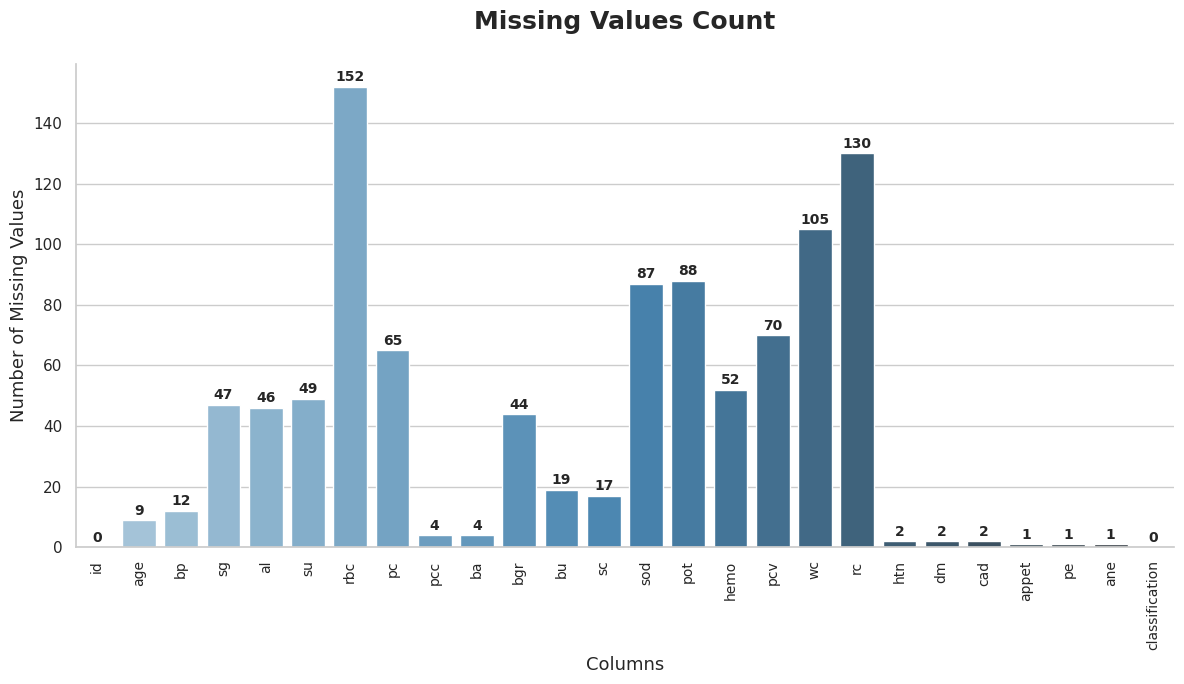

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=df.isnull().sum().index,
    y=df.isnull().sum().values,
    palette="Blues_d"
)

plt.title("Missing Values Count", fontsize=18, fontweight='bold', pad=25)
plt.xlabel("Columns", fontsize=13)
plt.ylabel("Number of Missing Values", fontsize=13)
plt.xticks(rotation=90, fontsize=10)
for i, v in enumerate(df.isnull().sum()):
    ax.text(i, v + 0.8, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()

In [ ]:
for col in df.columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\n After Filling Missing Values:")
display(df.head())


 After Filling Missing Values:


/tmp/ipykernel_3630/1639051571.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,...,38,6000,5.2,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,5.2,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [ ]:
df.replace({
    '\tno': 'no',
    '\tyes': 'yes',
    ' yes': 'yes',
    ' yes': 'yes'
}, inplace=True)

print("\n After Cleaning Text:")
display(df.head())


 After Cleaning Text:


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,...,38,6000,5.2,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,5.2,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [ ]:
df.replace({
    'yes': 1, 'no': 0,
    'present': 1, 'absent': 0,
    'abnormal': 1, 'normal': 0,
    'good': 1, 'poor': 0,
    'ckd': 1, 'notckd': 0
}, inplace=True)

print("\n After Encoding:")
display(df.head(50))

/tmp/ipykernel_3630/439814678.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({



 After Encoding:


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,0,0,notpresent,notpresent,...,44,7800,5.2,1,1,0,1,0,0,1
1,1,7.0,50.0,1.020,4.0,0.0,0,0,notpresent,notpresent,...,38,6000,5.2,0,0,0,1,0,0,1
2,2,62.0,80.0,1.010,2.0,3.0,0,0,notpresent,notpresent,...,31,7500,5.2,0,1,0,0,0,1,1
3,3,48.0,70.0,1.005,4.0,0.0,0,1,1,notpresent,...,32,6700,3.9,1,0,0,0,1,1,1
4,4,51.0,80.0,1.010,2.0,0.0,0,0,notpresent,notpresent,...,35,7300,4.6,0,0,0,1,0,0,1
5,5,60.0,90.0,1.015,3.0,0.0,0,0,notpresent,notpresent,...,39,7800,4.4,1,1,0,1,1,0,1
6,6,68.0,70.0,1.010,0.0,0.0,0,0,notpresent,notpresent,...,36,9800,5.2,0,0,0,1,0,0,1
7,7,24.0,80.0,1.015,2.0,4.0,0,1,notpresent,notpresent,...,44,6900,5,0,1,0,1,1,0,1
8,8,52.0,100.0,1.015,3.0,0.0,0,1,1,notpresent,...,33,9600,4.0,1,1,0,1,0,1,1
9,9,53.0,90.0,1.020,2.0,0.0,1,1,1,notpresent,...,29,12100,3.7,1,1,0,0,0,1,1


In [ ]:
df = df.apply(pd.to_numeric, errors='coerce')
df.fillna(0, inplace=True)

print("\n Final Clean Dataset:")
display(df.head())


 Final Clean Dataset:


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,0,0,0.0,0.0,...,44.0,7800.0,5.2,1,1,0,1,0,0,1.0
1,1,7.0,50.0,1.020,4.0,0.0,0,0,0.0,0.0,...,38.0,6000.0,5.2,0,0,0,1,0,0,1.0
2,2,62.0,80.0,1.010,2.0,3.0,0,0,0.0,0.0,...,31.0,7500.0,5.2,0,1,0,0,0,1,1.0
3,3,48.0,70.0,1.005,4.0,0.0,0,1,1.0,0.0,...,32.0,6700.0,3.9,1,0,0,0,1,1,1.0
4,4,51.0,80.0,1.010,2.0,0.0,0,0,0.0,0.0,...,35.0,7300.0,4.6,0,0,0,1,0,0,1.0


In [ ]:
df = df.drop('id', axis=1)
y = df['classification']
X = df.drop('classification', axis=1)

print("\n Features (X):")
display(X.head())
print("\n Target (y) distribution:")
print(y.value_counts())

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-Test Split Completed")
print(f"Training Data Shape : {X_train.shape}")
print(f"Testing Data Shape  : {X_test.shape}")
print(f"\nTarget distribution in Training:\n{y_train.value_counts()}")

from sklearn.preprocessing import StandardScaler


 Features (X):


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
0,48.0,80.0,1.020,1.0,0.0,0,0,0.0,0.0,121.0,...,15.4,44.0,7800.0,5.2,1,1,0,1,0,0
1,7.0,50.0,1.020,4.0,0.0,0,0,0.0,0.0,99.0,...,11.3,38.0,6000.0,5.2,0,0,0,1,0,0
2,62.0,80.0,1.010,2.0,3.0,0,0,0.0,0.0,423.0,...,9.6,31.0,7500.0,5.2,0,1,0,0,0,1
3,48.0,70.0,1.005,4.0,0.0,0,1,1.0,0.0,117.0,...,11.2,32.0,6700.0,3.9,1,0,0,0,1,1
4,51.0,80.0,1.010,2.0,0.0,0,0,0.0,0.0,106.0,...,11.6,35.0,7300.0,4.6,0,0,0,1,0,0



 Target (y) distribution:
classification
1.0    248
0.0    152
Name: count, dtype: int64
Train-Test Split Completed
Training Data Shape : (320, 24)
Testing Data Shape  : (80, 24)

Target distribution in Training:
classification
1.0    198
0.0    122
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Scaling Completed Successfully!\n")

print("After Scaling (First 5 rows):")
print(pd.DataFrame(X_train_scaled[:5], columns=X.columns).round(4))

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

 Scaling Completed Successfully!

After Scaling (First 5 rows):
      age      bp      sg      al      su     rbc      pc     pcc      ba  \
0 -2.4459  0.2178 -1.4091  1.6292 -0.3753 -0.3671 -0.4902 -0.3448 -0.2441   
1  0.4743 -0.5082 -1.4091  0.1026  2.5536  2.7242  2.0399 -0.3448 -0.2441   
2  0.7177  0.9437 -0.5000 -0.6607 -0.3753 -0.3671 -0.4902 -0.3448 -0.2441   
3 -0.9858  0.2178 -1.4091  0.1026 -0.3753  2.7242 -0.4902 -0.3448 -0.2441   
4  0.1702 -0.5082  0.4091 -0.6607 -0.3753 -0.3671 -0.4902 -0.3448 -0.2441   

      bgr  ...    hemo     pcv      wc      rc     htn      dm     cad  \
0 -0.5480  ...  0.7515  0.6590 -0.0194  0.3632 -0.7643 -0.6890 -0.3157   
1  3.7420  ... -0.0823 -0.2819  0.6334 -0.8174  1.3084  1.4515  3.1677   
2 -0.2312  ... -0.3950 -0.6347  1.1230 -0.1734 -0.7643 -0.6890 -0.3157   
3 -0.8120  ... -1.7152 -1.8107 -0.3050 -1.8906 -0.7643  1.4515 -0.3157   
4  1.2208  ... -0.3950  0.1885  0.4702  0.3632 -0.7643  1.4515 -0.3157   

    appet      pe     ane  


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

print("\n Logistic Regression Model Training Completed")

y_pred = model.predict(X_test_scaled)

result_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(" Prediction Completed for Logistic Regression!")
print("\nFirst 20 Predictions:")
display(result_df.head(20))

print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred):.4f} ({accuracy_score(y_test, y_pred)*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


 Logistic Regression Model Training Completed
 Prediction Completed for Logistic Regression!

First 20 Predictions:


,Actual,Predicted
340,0.0,0.0
205,1.0,1.0
233,1.0,1.0
364,0.0,0.0
121,1.0,1.0
29,1.0,1.0
399,0.0,0.0
218,1.0,1.0
217,1.0,1.0
116,1.0,1.0



Model Accuracy: 0.9750 (97.50%)

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97        30
         1.0       0.98      0.98      0.98        50

    accuracy                           0.97        80
   macro avg       0.97      0.97      0.97        80
weighted avg       0.97      0.97      0.97        80



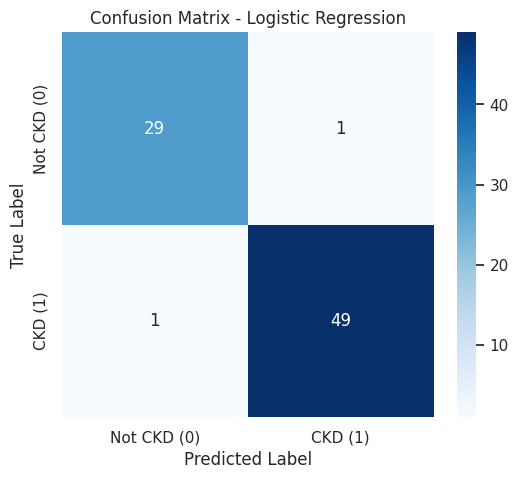

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not CKD (0)', 'CKD (1)'],
            yticklabels=['Not CKD (0)', 'CKD (1)'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# **K-Nearest Neighbors**:



In [ ]:

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
print("\n KNN Model Training Completed")

y_pred_knn = knn_model.predict(X_test_scaled)

result_df_knn = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_knn
})

print(" Prediction Completed for KNN!")
print("\nFirst 20 Predictions:")
display(result_df_knn.head(20))

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"\nKNN Model Accuracy: {accuracy_knn:.4f} ({accuracy_knn*100:.2f}%)")

print("\nClassification Report (KNN):")
print(classification_report(y_test, y_pred_knn))


 KNN Model Training Completed
 Prediction Completed for KNN!

First 20 Predictions:


,Actual,Predicted
340,0.0,0.0
205,1.0,1.0
233,1.0,1.0
364,0.0,0.0
121,1.0,1.0
29,1.0,1.0
399,0.0,0.0
218,1.0,1.0
217,1.0,1.0
116,1.0,1.0



KNN Model Accuracy: 0.9625 (96.25%)

Classification Report (KNN):
              precision    recall  f1-score   support

         0.0       0.94      0.97      0.95        30
         1.0       0.98      0.96      0.97        50

    accuracy                           0.96        80
   macro avg       0.96      0.96      0.96        80
weighted avg       0.96      0.96      0.96        80



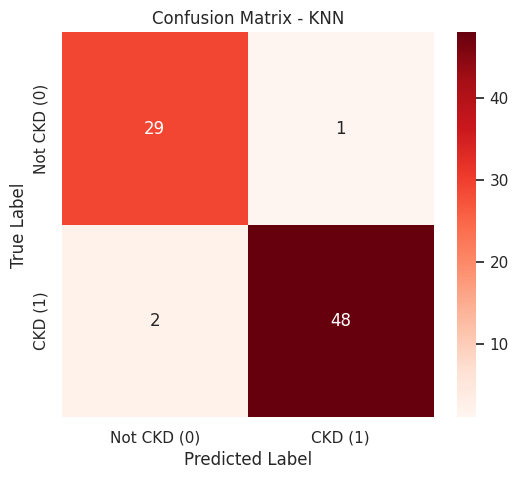

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not CKD (0)', 'CKD (1)'],
            yticklabels=['Not CKD (0)', 'CKD (1)'])

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Decision Tree:



In [ ]:

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)

print("\n Decision Tree Training Completed")

y_pred_dt = dt_model.predict(X_test_scaled)

result_df_dt = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_dt
})

print(" Prediction Completed for Decision Tree!")
print("\nFirst 20 Predictions:")
display(result_df_dt.head(20))

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"\nDecision Tree Accuracy: {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")

print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt))


 Decision Tree Training Completed
 Prediction Completed for Decision Tree!

First 20 Predictions:


,Actual,Predicted
340,0.0,0.0
205,1.0,0.0
233,1.0,0.0
364,0.0,0.0
121,1.0,1.0
29,1.0,1.0
399,0.0,0.0
218,1.0,1.0
217,1.0,1.0
116,1.0,1.0



Decision Tree Accuracy: 0.9375 (93.75%)

Classification Report (Decision Tree):
              precision    recall  f1-score   support

         0.0       0.93      0.90      0.92        30
         1.0       0.94      0.96      0.95        50

    accuracy                           0.94        80
   macro avg       0.94      0.93      0.93        80
weighted avg       0.94      0.94      0.94        80



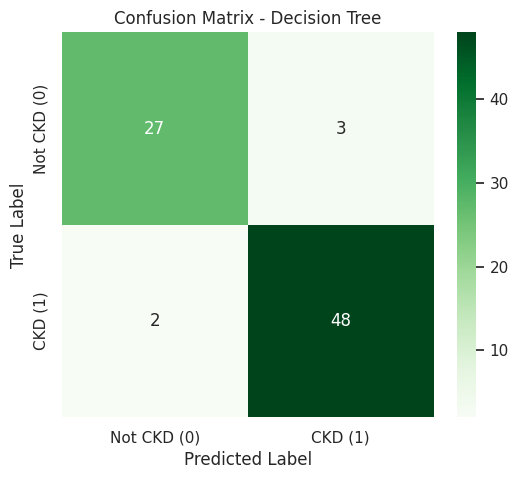

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not CKD (0)', 'CKD (1)'],
            yticklabels=['Not CKD (0)', 'CKD (1)'])

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Random Forest:

In [ ]:

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

print("\n Random Forest Training Completed")

y_pred_rf = rf_model.predict(X_test_scaled)

result_df_rf = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf
})

print(" Prediction Completed for Random Forest!")
print("\nFirst 20 Predictions:")
display(result_df_rf.head(20))

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nRandom Forest Accuracy: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))


 Random Forest Training Completed
 Prediction Completed for Random Forest!

First 20 Predictions:


,Actual,Predicted
340,0.0,0.0
205,1.0,1.0
233,1.0,1.0
364,0.0,0.0
121,1.0,1.0
29,1.0,1.0
399,0.0,0.0
218,1.0,1.0
217,1.0,1.0
116,1.0,1.0



Random Forest Accuracy: 0.9875 (98.75%)

Classification Report (Random Forest):
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98        30
         1.0       0.98      1.00      0.99        50

    accuracy                           0.99        80
   macro avg       0.99      0.98      0.99        80
weighted avg       0.99      0.99      0.99        80



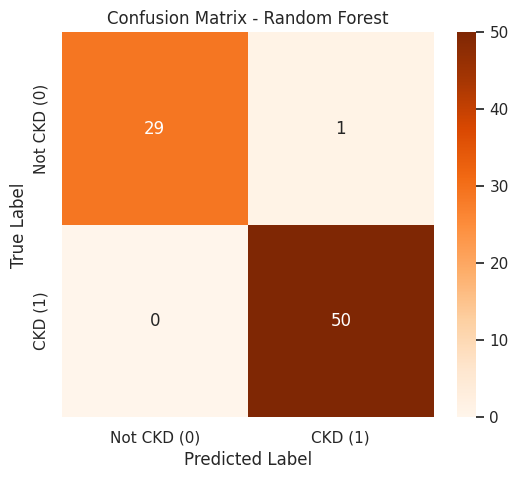

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not CKD (0)', 'CKD (1)'],
            yticklabels=['Not CKD (0)', 'CKD (1)'])

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Model Accuracy Comparison:

/tmp/ipykernel_3630/777964529.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


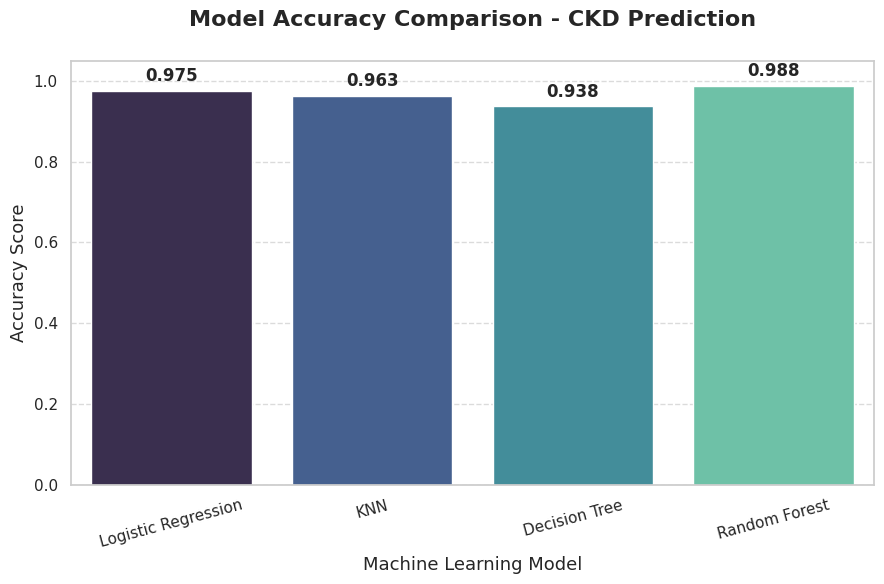

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
results_df = pd.DataFrame({
    "Model Name": ["Logistic Regression", "KNN", "Decision Tree", "Random Forest"],
    "Accuracy Score": [accuracy_score(y_test, y_pred),
                       accuracy_knn,
                       accuracy_dt,
                       accuracy_rf]
})

plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(
    data=results_df,
    x="Model Name",
    y="Accuracy Score",
    palette="mako"
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=4, fontsize=12, fontweight='bold')

plt.ylim(0, 1.05)
plt.title("Model Accuracy Comparison - CKD Prediction",
          fontsize=16,
          fontweight='bold',
          pad=25)
plt.ylabel("Accuracy Score", fontsize=13)
plt.xlabel("Machine Learning Model", fontsize=13)
plt.xticks(rotation=15, fontsize=11)


plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()